# Citation graph actual

A directed network of the reviewed research papers: **A → B means that paper A cites paper B.**
Nodes are canonical works; links are recorded citations between those works. The default snapshot
contains 294 selected PDFs mapped to 292 works and 2,539 links.

Run all cells using **Python (batill)**. This notebook reads the existing reviewed OpenAlex data
and runs offline. It needs the project's `citations`, `analysis` and `notebook` extras
(`python -m pip install -e '.[citations,analysis,notebook]'` if recreating the environment).
Results go to `outputs/citation_graph_actual/9ad47e071ee12c2f/`.

The overview uses citation links to position papers, node size for **citations received within
this selection**, and color for publication year. The interactive view supports zoom, pan and
hover. A separate paper view exposes incoming/outgoing links and their evidence; edit
`FOCUS_PAPER` near the end to explore another paper.

This is a visualization of direct citations, with no clustering or embedding computation.
The extraction workflows remain in `Citation_graph_OpenAlex.ipynb` and `Citation_graph.ipynb`.

In [1]:
from pathlib import Path
from html import escape
import hashlib
import json
import platform
import textwrap
from importlib.metadata import version

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import plotly.graph_objects as go
from IPython.display import display, Markdown

ROOT = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
             if (p / 'src' / 'batill').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the batill project directory.')

SELECTION_ID = '9ad47e071ee12c2f'
DATA_DIR = ROOT / 'outputs' / 'citation_graph_openalex' / SELECTION_ID / 'reviewed'
OUT = ROOT / 'outputs' / 'citation_graph_actual' / SELECTION_ID
SEED = 42
required = ['nodes.csv', 'edges.csv', 'pdf_to_work.csv', 'citation_graph.graphml', 'report.md']
missing = [name for name in required if not (DATA_DIR / name).is_file()]
if missing:
    raise FileNotFoundError(f'Missing reviewed inputs in {DATA_DIR}: {missing}')
OUT.mkdir(parents=True, exist_ok=True)
print('Reviewed inputs:', DATA_DIR.relative_to(ROOT))
print('Graph outputs:', OUT.relative_to(ROOT))

Reviewed inputs: outputs/citation_graph_openalex/9ad47e071ee12c2f/reviewed
Graph outputs: outputs/citation_graph_actual/9ad47e071ee12c2f


## 1. Load and verify the directed graph

Every canonical work is added before edges, so isolates are retained. PDF aliases are mapped
to their canonical work. The CSV graph is checked against the saved reviewed GraphML and
stored degree counts to catch stale or inconsistent inputs.

In [2]:
nodes = pd.read_csv(DATA_DIR / 'nodes.csv', dtype=str, keep_default_na=False)
edges = pd.read_csv(DATA_DIR / 'edges.csv', dtype=str, keep_default_na=False)
pdf_map = pd.read_csv(DATA_DIR / 'pdf_to_work.csv', dtype=str, keep_default_na=False)
assert nodes['Key'].is_unique and nodes.paper_id.is_unique, 'Duplicate canonical nodes'
assert not edges.duplicated(['source_key', 'target_key']).any(), 'Duplicate citation edges'
key_to_id = nodes.set_index('Key').paper_id.to_dict()
for side in ['source', 'target']:
    assert edges[f'{side}_key'].isin(key_to_id).all(), f'Unknown {side} work'
    assert edges[f'{side}_key'].map(key_to_id).equals(edges[f'{side}_paper_id']), 'ID mismatch'
assert pdf_map.Key.is_unique and pdf_map.paper_id.is_unique
assert pdf_map.canonical_key.map(key_to_id).equals(pdf_map.canonical_paper_id)
assert set(pdf_map.canonical_key) == set(nodes.Key)
assert set(edges.citation_source) <= {'openalex', 'local_pdf_manual_review'}

G = nx.DiGraph(selection_id=SELECTION_ID, direction='source cites target')
for row in nodes.to_dict('records'):
    paper_id = row.pop('paper_id')
    row['title'] = row['openalex_title'] or row['query_title'] or row['extracted_title']
    row['year'] = int(row['openalex_year'] or row['query_year'])
    G.add_node(paper_id, **row)
for row in edges.to_dict('records'):
    source, target = row.pop('source_paper_id'), row.pop('target_paper_id')
    G.add_edge(source, target, **row)
assert nx.number_of_selfloops(G) == 0, 'Unexpected work-level self-citation'

saved_graph = nx.read_graphml(DATA_DIR / 'citation_graph.graphml')
assert saved_graph.is_directed()
assert set(saved_graph) == set(nodes.Key)
assert set(saved_graph.edges()) == set(zip(edges.source_key, edges.target_key))
for paper_id, data in G.nodes(data=True):
    assert G.in_degree(paper_id) == int(data['internal_in_degree'])
    assert G.out_degree(paper_id) == int(data['internal_out_degree'])

components = sorted(nx.weakly_connected_components(G), key=lambda c: (-len(c), min(c)))
component_id = {p: i + 1 for i, component in enumerate(components) for p in component}
metrics = pd.DataFrame([
    {'paper_id': p, 'title': d['title'], 'year': d['year'],
     'citations_received': G.in_degree(p), 'references_to_selected_works': G.out_degree(p),
     'weak_component': component_id[p], 'isolated': G.degree(p) == 0,
     'reference_coverage_note': d['reference_coverage_note']}
    for p, d in G.nodes(data=True)
]).sort_values(['citations_received', 'paper_id'], ascending=[False, True])
display(pd.Series({
    'Selected PDFs': len(pdf_map), 'Canonical works': len(G),
    'Directed citations': G.number_of_edges(),
    'Manually verified citations': int(edges.citation_source.eq('local_pdf_manual_review').sum()),
    'Weakly connected components': len(components),
    'Works in largest component': len(components[0]),
    'Isolates': nx.number_of_isolates(G),
}, name='Count').to_frame())
display(metrics.head(15).reset_index(drop=True))

,Count
Selected PDFs,294
Canonical works,292
Directed citations,2539
Manually verified citations,65
Weakly connected components,5
Works in largest component,286
Isolates,3


,paper_id,title,year,citations_received,references_to_selected_works,weak_component,isolated,reference_coverage_note
0,P227,"Private Equity Performance: Returns, Persisten...",2005,116,3,1,False,provider_list_completeness_unknown
1,P229,Leveraged Buyouts and Private Equity,2009,96,31,1,False,provider_list_completeness_unknown
2,P224,The effects of management buyouts on operating...,1989,87,2,1,False,provider_list_completeness_unknown
3,P266,The Economics of Private Equity Funds,2010,66,8,1,False,provider_list_completeness_unknown
4,P191,Do Buyouts (Still) Create Value?,2011,62,13,1,False,provider_list_completeness_unknown
5,P199,Private Equity Performance: What Do We Know?,2014,61,5,1,False,provider_list_completeness_unknown
6,P247,"Smart Institutions, Foolish Choices: The Limit...",2007,55,3,1,False,provider_list_completeness_unknown
7,P021,"Borrow Cheap, Buy High? The Determinants of Le...",2013,49,17,1,False,provider_list_completeness_unknown
8,P287,The Performance of Private Equity Funds,2008,46,5,1,False,provider_list_completeness_unknown
9,P003,Corporate Governance and Value Creation: Evide...,2012,41,17,1,False,provider_list_completeness_unknown


## 2. Layout and static overview

A seeded spring layout places linked papers near one another. It uses undirected connectivity
**only for positioning**; all displayed edges and degree counts retain citation direction.
Disconnected components appear in a separate column on the right, including all isolates.
Distances between components are arbitrary. Positions do not encode topic similarity or time.

Gray arrows are OpenAlex links; orange arrows are manually verified PDF links. Larger circles
receive more citations from the selected works. Labels identify the most cited works and all
works outside the largest component; hover in the interactive view to identify any paper.

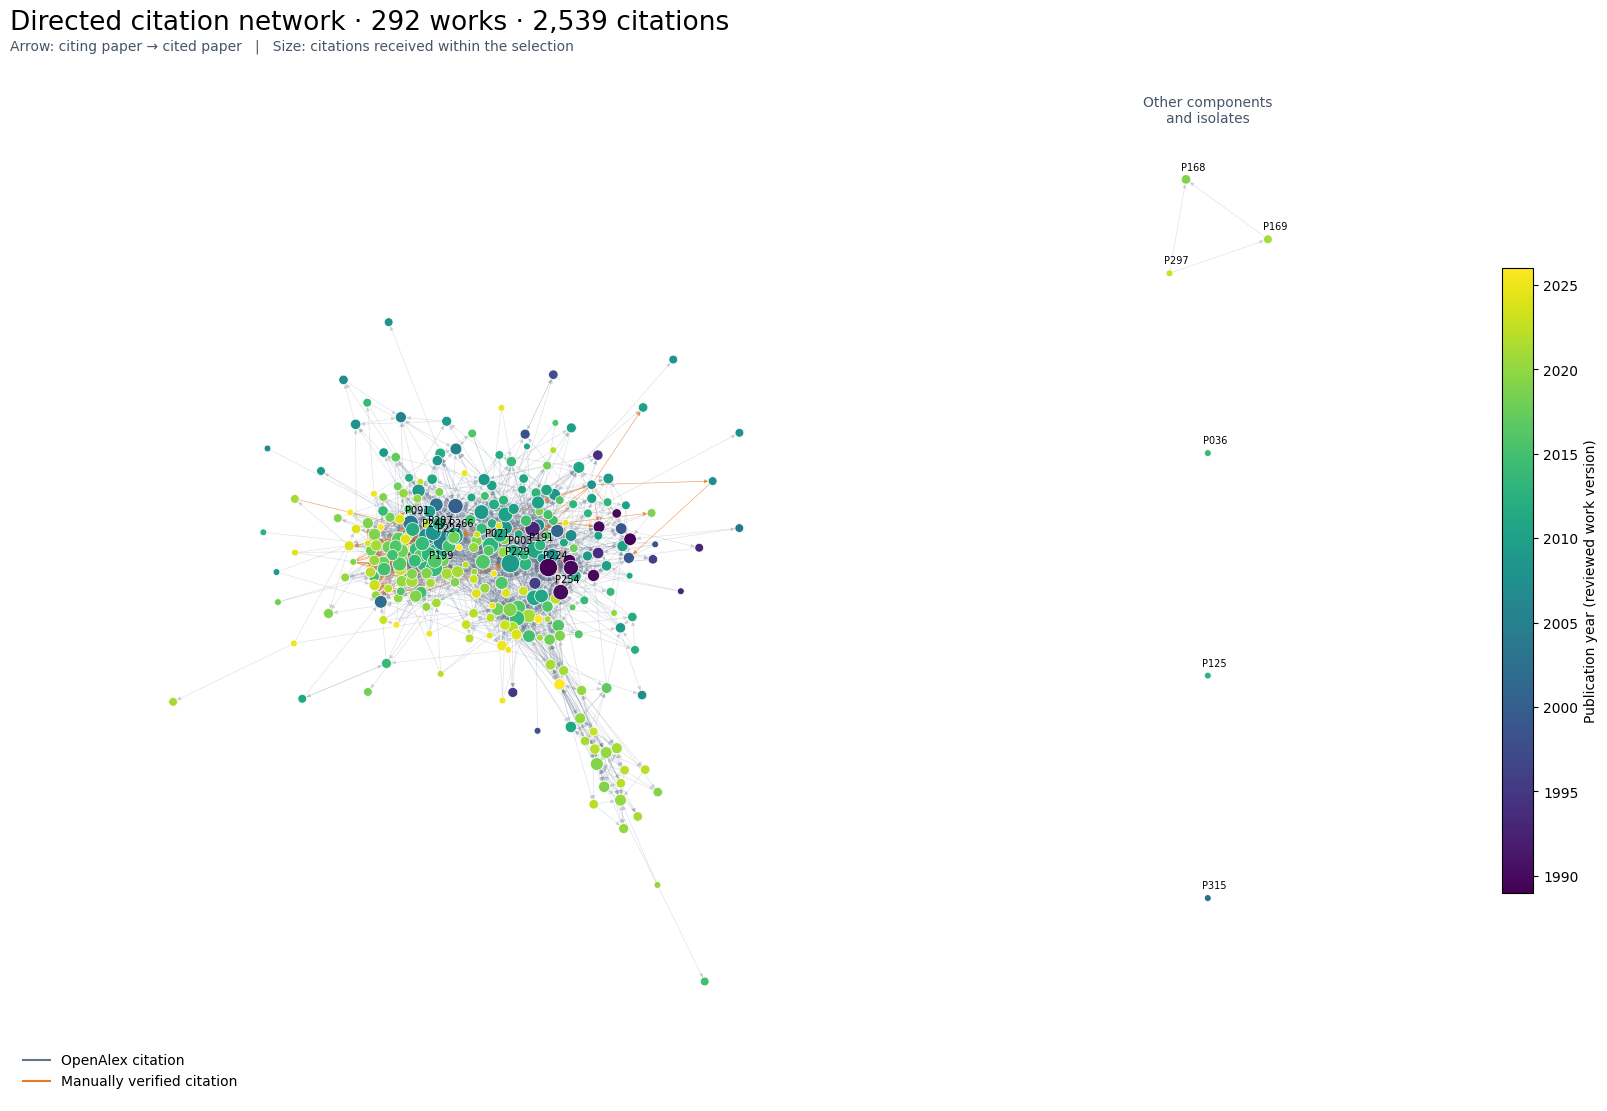

In [3]:
def component_layout(graph):
    parts = sorted(nx.weakly_connected_components(graph), key=lambda c: (-len(c), min(c)))
    positions = {}
    for index, part in enumerate(parts):
        sub = graph.subgraph(sorted(part)).to_undirected()
        local = nx.spring_layout(sub, seed=SEED, iterations=250, scale=1.0)
        if index == 0:
            positions.update(local)
        else:
            y = 0.8 - (index - 1) * 1.6 / max(1, len(parts) - 2)
            positions.update({p: np.asarray(xy) * 0.13 + [1.55, y] for p, xy in local.items()})
    return positions

pos = component_layout(G)
node_order = list(G)
years = [G.nodes[p]['year'] for p in node_order]
year_min, year_max = min(years), max(years)
edge_colors = {'openalex': '#64748b', 'local_pdf_manual_review': '#e87924'}
node_sizes = {p: 24 + 16 * np.sqrt(G.in_degree(p)) for p in G}
labels = set(metrics.head(12).paper_id) | set().union(*components[1:])

fig, ax = plt.subplots(figsize=(16, 11), layout='constrained')
for kind, color in edge_colors.items():
    subset = [(a, b) for a, b, d in G.edges(data=True) if d['citation_source'] == kind]
    nx.draw_networkx_edges(G, pos, edgelist=subset, ax=ax, arrows=True,
        arrowstyle='-|>', arrowsize=6, width=0.45, alpha=0.22 if kind == 'openalex' else 0.7,
        edge_color=color, node_size=[node_sizes[p] for p in node_order], nodelist=node_order)
points = nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=node_order,
    node_size=[node_sizes[p] for p in node_order], node_color=years,
    cmap='viridis', vmin=year_min, vmax=year_max, edgecolors='white', linewidths=0.5)
nx.draw_networkx_labels(G, {p: xy + [0.015, 0.03] for p, xy in pos.items()},
    labels={p: p for p in labels}, ax=ax, font_size=7)
fig.colorbar(points, ax=ax, shrink=0.6, label='Publication year (reviewed work version)')
ax.legend(handles=[Line2D([0], [0], color=color, label=label)
    for color, label in [(edge_colors['openalex'], 'OpenAlex citation'),
                         (edge_colors['local_pdf_manual_review'], 'Manually verified citation')]],
    loc='lower left', frameon=False)
ax.set_title(f'Directed citation network · {len(G)} works · {G.number_of_edges():,} citations',
             loc='left', fontsize=19, pad=22)
ax.text(0, 1.01, 'Arrow: citing paper → cited paper   |   Size: citations received within the selection',
        transform=ax.transAxes, fontsize=10, color='#475569')
if len(components) > 1:
    ax.text(1.55, 1.06, 'Other components\nand isolates', ha='center', fontsize=10, color='#475569')
ax.margins(0.09)
ax.set_axis_off()
fig.savefig(OUT / 'citation_graph.png', dpi=200, bbox_inches='tight')
fig.savefig(OUT / 'citation_graph.svg', bbox_inches='tight')
plt.show()

## 3. Interactive citation graph

Zoom or pan to inspect dense regions. Hover over a **node** for its title, ID, year, degree
counts and reference-coverage note. Hover over an **arrowhead** for the citing/cited IDs,
matching method, provenance and manual evidence page when available. Arrowheads sit partway
along each link and point toward the cited work. Double-click to reset the view.

The exported HTML includes Plotly itself and opens offline in a browser. Colors and node
sizes use the same corpus-wide scale in the overview and the focused view.

In [4]:
def wrapped_html(value, width=65):
    return '<br>'.join(escape(line) for line in textwrap.wrap(str(value), width))

def interactive_graph(graph, positions, title, label_all=False):
    figure = go.Figure()
    for kind, color in edge_colors.items():
        selected = [(a, b, d) for a, b, d in graph.edges(data=True) if d['citation_source'] == kind]
        if not selected:
            continue
        line_x, line_y, arrow_x, arrow_y, angles, hover = [], [], [], [], [], []
        for a, b, data in selected:
            start, end = np.asarray(positions[a]), np.asarray(positions[b])
            line_x.extend([start[0], end[0], None])
            line_y.extend([start[1], end[1], None])
            point = start + 0.72 * (end - start)
            arrow_x.append(point[0]); arrow_y.append(point[1])
            delta = end - start
            angles.append(float(90 - np.degrees(np.arctan2(delta[1], delta[0]))))
            hover.append(f'<b>{a} → {b}</b><br>'
                f'{wrapped_html(G.nodes[a]["title"])}<br>cites<br>'
                f'{wrapped_html(G.nodes[b]["title"])}<br><br>'
                f'Source: {escape(kind)}<br>Match: {escape(data["target_match_method"])}<br>'
                f'PDF evidence page: {escape(data["evidence_pdf_page"] or "—")}')
        label = 'OpenAlex citation' if kind == 'openalex' else 'Manually verified citation'
        figure.add_trace(go.Scatter(x=line_x, y=line_y, mode='lines', name=label,
            legendgroup=kind, line=dict(color=color, width=0.6),
            opacity=0.20 if kind == 'openalex' else 0.7, hoverinfo='skip'))
        figure.add_trace(go.Scatter(x=arrow_x, y=arrow_y, mode='markers',
            marker=dict(symbol='triangle-up', angle=angles, size=5, color=color),
            opacity=0.5, text=hover, hovertemplate='%{text}<extra></extra>',
            showlegend=False, legendgroup=kind))
    papers = list(graph)
    hover = []
    for p in papers:
        data = G.nodes[p]
        aliases = pdf_map.loc[pdf_map.canonical_paper_id.eq(p), 'paper_id'].tolist()
        hover.append(f'<b>{p} · {data["year"]}</b><br>{wrapped_html(data["title"])}<br><br>'
            f'Incoming citations in selection: {G.in_degree(p)}<br>'
            f'Outgoing references in selection: {G.out_degree(p)}<br>'
            f'PDF IDs: {", ".join(aliases)}<br>'
            f'Coverage: {wrapped_html(data["reference_coverage_note"])}')
    figure.add_trace(go.Scatter(
        x=[positions[p][0] for p in papers], y=[positions[p][1] for p in papers],
        mode='markers+text', name='Works', showlegend=False,
        text=[p if label_all or p in labels else '' for p in papers],
        textposition='top center', textfont=dict(size=10), customdata=papers,
        hovertext=hover, hovertemplate='%{hovertext}<extra></extra>',
        marker=dict(size=[8 + 2.0 * np.sqrt(G.in_degree(p)) for p in papers],
            color=[G.nodes[p]['year'] for p in papers], colorscale='Viridis',
            cmin=year_min, cmax=year_max, showscale=True,
            colorbar=dict(title='Publication<br>year', thickness=14),
            line=dict(width=0.7, color='white'))))
    figure.update_layout(title=dict(text=title, font=dict(size=20)),
        template='plotly_white', height=820, hovermode='closest',
        margin=dict(l=20, r=40, t=90, b=70),
        legend=dict(orientation='h', y=-0.04),
        xaxis=dict(visible=False), yaxis=dict(visible=False, scaleanchor='x', scaleratio=1),
        annotations=[dict(text='Arrow: citing → cited · Size: incoming citations in the full selection',
                          x=0, y=1.045, xref='paper', yref='paper', showarrow=False, xanchor='left')])
    return figure

overview = interactive_graph(G, pos, f'Citation graph · {len(G)} works · {G.number_of_edges():,} links')
overview.write_html(OUT / 'citation_graph_interactive.html', include_plotlyjs=True,
                    config={'scrollZoom': True, 'displaylogo': False})
overview.show(renderer='plotly_mimetype', config={'scrollZoom': True, 'displaylogo': False})
print('Offline interactive graph:', OUT / 'citation_graph_interactive.html')

Offline interactive graph: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/citation_graph_actual/9ad47e071ee12c2f/citation_graph_interactive.html


## 4. Explore one paper and its citation evidence

Search titles or paper IDs below, then set `FOCUS_PAPER` to a paper ID (for example `P001`,
`P227`, or the duplicate PDF alias `P308`). `DIRECTION` accepts `both`, `incoming`, or `outgoing`.
The view shows only direct links involving the chosen paper. Node sizes still describe the
full graph. Incoming means **other papers cite the focal paper**; outgoing means **the focal
paper cites other papers**. An isolate is displayed as a single node.

In [5]:
SEARCH = 'private equity'  # Change to a title fragment or paper ID; empty string shows all.
matches = metrics.loc[
    metrics.title.str.contains(SEARCH, case=False, regex=False)
    | metrics.paper_id.str.contains(SEARCH, case=False, regex=False)
]
display(matches.reset_index(drop=True))

,paper_id,title,year,citations_received,references_to_selected_works,weak_component,isolated,reference_coverage_note
0,P227,"Private Equity Performance: Returns, Persisten...",2005,116,3,1,False,provider_list_completeness_unknown
1,P229,Leveraged Buyouts and Private Equity,2009,96,31,1,False,provider_list_completeness_unknown
2,P266,The Economics of Private Equity Funds,2010,66,8,1,False,provider_list_completeness_unknown
3,P199,Private Equity Performance: What Do We Know?,2014,61,5,1,False,provider_list_completeness_unknown
4,P287,The Performance of Private Equity Funds,2008,46,5,1,False,provider_list_completeness_unknown
...,...,...,...,...,...,...,...,...
191,P147,Politically Connected Private Equity and Emplo...,2017,0,9,1,False,provider_list_completeness_unknown
192,P187,Evaluating Private Equity Performance Using St...,2019,0,9,1,False,partial_internal_pdf_recovery; external_biblio...
193,P218,Long Goodbyes: How Do Private Equity Funds Man...,2025,0,5,1,False,provider_list_completeness_unknown
194,P236,Private Equity for Pension Plans? Evaluating P...,2024,0,21,1,False,partial_internal_pdf_recovery; external_biblio...


In [6]:
FOCUS_PAPER = 'P001'
DIRECTION = 'both'

alias_to_canonical = pdf_map.set_index('paper_id').canonical_paper_id.to_dict()

def paper_neighborhood(paper_id, direction='both'):
    if direction not in {'both', 'incoming', 'outgoing'}:
        raise ValueError('DIRECTION must be both, incoming, or outgoing.')
    focal = alias_to_canonical.get(paper_id.strip().upper(), paper_id.strip().upper())
    if focal not in G:
        raise ValueError(f'Unknown paper ID: {paper_id}. Use the search cell above.')
    links = set()
    if direction in {'both', 'incoming'}:
        links.update(G.in_edges(focal))
    if direction in {'both', 'outgoing'}:
        links.update(G.out_edges(focal))
    neighborhood = G.edge_subgraph(sorted(links)).copy()
    neighborhood.add_node(focal, **G.nodes[focal])
    return focal, neighborhood

focal, neighborhood = paper_neighborhood(FOCUS_PAPER, DIRECTION)
focus_pos = nx.spring_layout(neighborhood.to_undirected(), seed=SEED, iterations=250)
display(Markdown(f'**{focal}: {escape(G.nodes[focal]["title"])}**'))
print(f'{DIRECTION}: {len(neighborhood)} works, {neighborhood.number_of_edges()} direct links')
focus_figure = interactive_graph(neighborhood, focus_pos,
    f'{focal} · {DIRECTION} citations · {neighborhood.number_of_edges()} links', label_all=True)
focus_figure.write_html(OUT / f'paper_{focal}_{DIRECTION}.html', include_plotlyjs=True,
                        config={'scrollZoom': True, 'displaylogo': False})
focus_figure.show(renderer='plotly_mimetype', config={'scrollZoom': True, 'displaylogo': False})

def citation_table(paper_id, incoming):
    mask = edges.target_paper_id.eq(paper_id) if incoming else edges.source_paper_id.eq(paper_id)
    table = edges.loc[mask].copy()
    table.insert(1, 'source_title', table.source_paper_id.map(lambda p: G.nodes[p]['title']))
    table.insert(3, 'target_title', table.target_paper_id.map(lambda p: G.nodes[p]['title']))
    return table[['source_paper_id', 'source_title', 'target_paper_id', 'target_title',
                  'citation_source', 'target_match_method', 'evidence_pdf_page']].reset_index(drop=True)

incoming = citation_table(focal, incoming=True)
outgoing = citation_table(focal, incoming=False)
display(Markdown(f'**Incoming citations — {len(incoming)} papers cite {focal}**'))
display(incoming)
display(Markdown(f'**Outgoing references — {focal} cites {len(outgoing)} selected papers**'))
display(outgoing)
incoming.to_csv(OUT / f'paper_{focal}_incoming.csv', index=False)
outgoing.to_csv(OUT / f'paper_{focal}_outgoing.csv', index=False)

**P001: ESG Disclosures in the Private Equity Industry**

both: 10 works, 9 direct links


**Incoming citations — 0 papers cite P001**

,source_paper_id,source_title,target_paper_id,target_title,citation_source,target_match_method,evidence_pdf_page


**Outgoing references — P001 cites 9 selected papers**

,source_paper_id,source_title,target_paper_id,target_title,citation_source,target_match_method,evidence_pdf_page
0,P001,ESG Disclosures in the Private Equity Industry,P108,"Think Global, Invest Responsible: Why the Priv...",openalex,primary_work_id,
1,P001,ESG Disclosures in the Private Equity Industry,P107,"The price of environmental, social and governa...",openalex,primary_work_id,
2,P001,ESG Disclosures in the Private Equity Industry,P034,Does Private Equity Ownership Make Firms Clean...,openalex,verified_doi_version_alias,
3,P001,ESG Disclosures in the Private Equity Industry,P116,"Private Equity, Jobs, and Productivity",openalex,primary_work_id,
4,P001,ESG Disclosures in the Private Equity Industry,P015,Private equity and human capital risk,openalex,primary_work_id,
5,P001,ESG Disclosures in the Private Equity Industry,P130,When Investor Incentives and Consumer Interest...,openalex,primary_work_id,
6,P001,ESG Disclosures in the Private Equity Industry,P220,Does Mandatory Disclosure Matter for Private E...,openalex,primary_work_id,
7,P001,ESG Disclosures in the Private Equity Industry,P276,Private Equity and Local Public Finances,openalex,primary_work_id,
8,P001,ESG Disclosures in the Private Equity Industry,P127,Can Limited Partners Mitigate Negative Externa...,openalex,primary_work_id,


## 5. Save the graph and reproducibility information

Exports include the directed GraphML (paper IDs as node IDs, original hashes and evidence
retained as attributes), node metrics, overview coordinates, PNG/SVG overview, standalone
interactive HTML and focal-paper citation tables. These files are separate from the reviewed
input snapshot. Rerunning refreshes the same visualization outputs.

**Interpretation limits:** this is the induced graph on the selected works; external cited
works are absent. Degree counts are within-corpus counts, not global citation totals.
Publication years describe the reviewed work version, which can differ from the local PDF.
Provider lists can be incomplete; eight papers have partial manual reference supplementation.
An absent edge or isolated paper does not prove absence of a citation or thematic relevance.
See the reviewed `report.md` and `manual_citation_evidence.csv` for the recorded review.

In [7]:
metrics.to_csv(OUT / 'node_metrics.csv', index=False)
coordinates = pd.DataFrame([{'paper_id': p, 'x': float(xy[0]), 'y': float(xy[1]),
                              'weak_component': component_id[p]} for p, xy in pos.items()])
coordinates.to_csv(OUT / 'layout.csv', index=False)
nx.write_graphml(G, OUT / 'citation_graph_actual.graphml')

manifest = {
    'selection_id': SELECTION_ID,
    'inputs': {str((DATA_DIR / name).relative_to(ROOT)):
               hashlib.sha256((DATA_DIR / name).read_bytes()).hexdigest() for name in required},
    'notebook_sha256': hashlib.sha256('\n'.join(
        ''.join(c['source']) for c in json.loads((ROOT / 'citation graph actual.ipynb').read_text())['cells']
    ).encode()).hexdigest(),
    'nodes': len(G), 'directed_edges': G.number_of_edges(),
    'edge_direction': 'citing paper -> cited paper',
    'layout': 'spring layout per weak component, undirected positioning only',
    'layout_seed': SEED, 'layout_iterations': 250,
    'node_size': 'within-selection in-degree', 'node_color': 'reviewed publication year',
    'focus_paper': focal, 'focus_direction': DIRECTION,
    'python': platform.python_version(),
    'versions': {name: version(name) for name in ['networkx', 'numpy', 'pandas', 'matplotlib', 'plotly']},
}
(OUT / 'run_manifest.json').write_text(json.dumps(manifest, indent=2) + '\n')
print('Saved graph, figures, tables and manifest to:', OUT)

Saved graph, figures, tables and manifest to: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/citation_graph_actual/9ad47e071ee12c2f
